# Body Shape At Release

Slide-ready visualization for the **top-left cluster** story: a low-xG shot where the player still creates a high-quality strike through release mechanics.

Default selected shot: **Serge Gnabry**, Bayern vs Hamburg, event `18902400000048`.

Design target: a left-side **visualizer-style 3D pitch/mechanics panel** with the clean white/red Bundesliga presentation system around it.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path("final-repo/metrics-calculation/notebooks").resolve()
METRICS_DIR = NOTEBOOK_DIR.parent
REF_DIR = METRICS_DIR / "reference_outputs"
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SRC_DIR = METRICS_DIR.parent / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RED = "#C4050E"
DARK_RED = "#900000"
INK = "#111111"
TITLE_INK = "#171717"
MUTED = "#666666"
GRID = "#D9D9D9"
LIGHT = "#F3F3F3"
BG = "#FFFFFF"
PITCH = "#326B46"
PITCH_DARK = "#26583A"
CYAN = "#72B6BE"
ORANGE = "#E58A3A"
PINK = "#F66093"
BALL = "#F2BF5E"

# Google Sans Flex can render badly in some Matplotlib installs; Google Sans/Arial keeps the deck look stable.
FONT = ["Google Sans", "Arial", "DejaVu Sans", "sans-serif"]
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "font.family": FONT,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "svg.fonttype": "none",
})
print(f"Reference outputs: {REF_DIR}")
print(f"Figure outputs: {FIG_DIR}")

Reference outputs: /Users/tayyabkhan/Downloads/aws/final-repo/metrics-calculation/reference_outputs
Figure outputs: /Users/tayyabkhan/Downloads/aws/final-repo/metrics-calculation/notebooks/figures


## 1. Pick A Shot That Explains The Top-Left Cluster

The selected shot is low xG but high BSQ, which makes it a natural bridge from the scatterplot into body-shape mechanics.

In [2]:
scores = pd.read_csv(REF_DIR / "scores_v1.csv")
shots = pd.read_csv(REF_DIR / "shots.csv")

shot_cols = [
    "event_id", "player_name", "team_name", "player_id", "match_folder", "xg",
    "shot_result", "shot_foot", "parquet_key", "distance_to_goal", "angle_to_goal", "pressure",
]
df = scores.merge(shots[shot_cols], on=["event_id", "match_folder"], how="left", suffixes=("", "_shot"))

PREFERRED_EVENT_ID = 18902400000048  # Serge Gnabry: low xG, high BSQ, successful shot.
if PREFERRED_EVENT_ID in set(df["event_id"]):
    shot = df.loc[df["event_id"] == PREFERRED_EVENT_ID].iloc[0]
else:
    shot = (
        df.loc[(df["xg"] <= 0.08) & (df["Q"] >= 0.75)]
        .sort_values(["Q", "finishing_execution_index"], ascending=False)
        .iloc[0]
    )

summary_cols = [
    "event_id", "player_name", "team_name", "match_folder", "shot_result_shot", "shot_foot", "xg", "Q",
    "finishing_execution_index", "technique_mechanics_score", "strike_quality_score", "placement_score",
    "P3_score", "P4_score", "P5_score", "P6_score", "ball_exit_speed_m_s", "launch_angle_deg",
]
pd.DataFrame([shot[summary_cols]]).T.rename(columns={shot.name: "selected_shot"})

,selected_shot
event_id,18902400000048
player_name,Serge Gnabry
team_name,FC Bayern München
match_folder,Bayern_Hamburg
shot_result_shot,successfulShot
shot_foot,right
xg,0.0308
Q,0.88644
finishing_execution_index,87.401487
technique_mechanics_score,78.4491


## 2. Visualizer-Style Mechanics View

The left panel deliberately follows the 3D visualizer language: dark-green pitch, compact body at release, highlighted striking leg, ball/release trail. The right panel stays presentation-clean with metric bars and a phase rail.

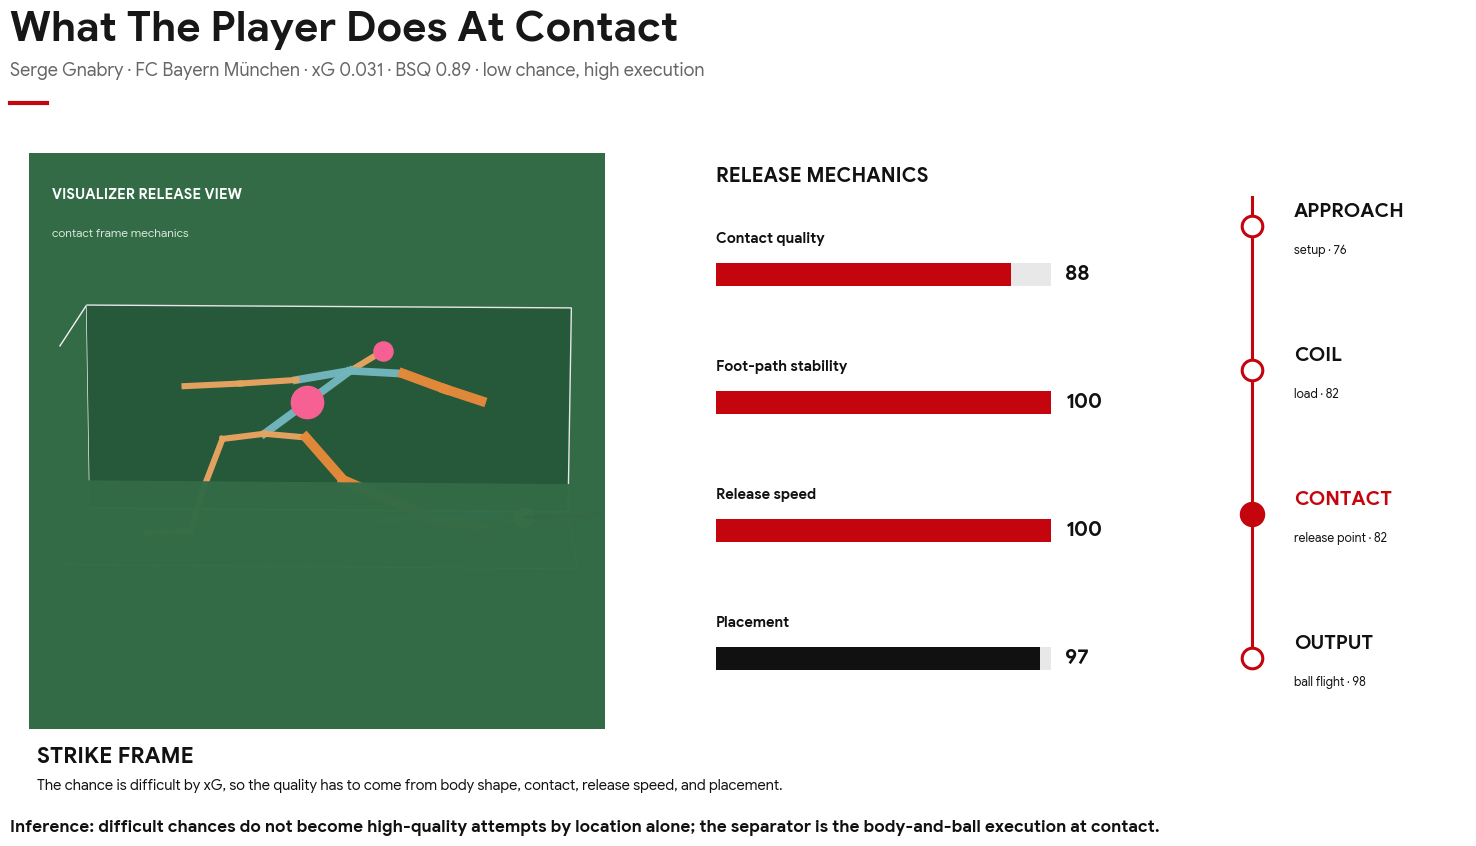

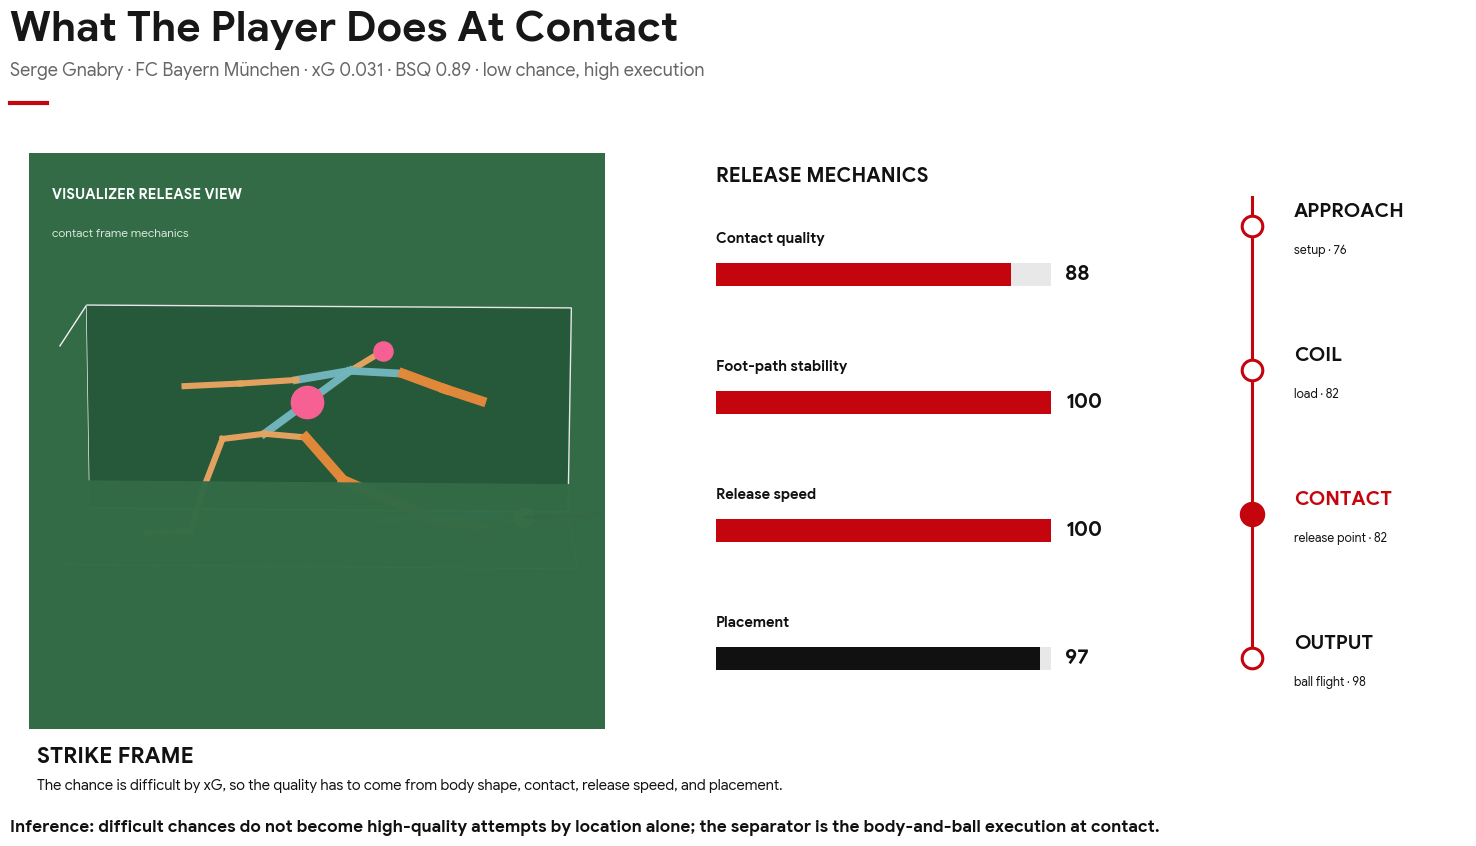

In [3]:
def score_0_100(row, column):
    value = row.get(column)
    if pd.isna(value):
        return np.nan
    value = float(value)
    return value * 100 if value <= 1.5 else value


def rotate_xy(v, deg):
    rad = math.radians(float(deg))
    c, s = math.cos(rad), math.sin(rad)
    x, y = v
    return np.array([c*x - s*y, s*x + c*y])


def visualizer_pose(row):
    """Feature-informed, visualizer-style release pose for slide rendering."""
    foot = str(row.get("shot_foot", "right") or "right").lower()
    right_footed = foot.startswith("right")
    sep = float(row.get("shoulder_hip_separation_deg", 18) or 18)
    contact_score = float(row.get("C_contact_near_ankle", 0.75) or 0.75)
    release_score = float(row.get("V_exit_speed", 0.75) or 0.75)
    lean = np.clip(float(row.get("torso_lean_deg", 10) or 10), -18, 26) / 26

    # Compact body, intentionally side-on like the review visualizer.
    pelvis = np.array([0.00, 0.00, 0.70])
    neck = np.array([0.34 + 0.08*lean, 0.02, 1.12])
    head = np.array([0.48 + 0.08*lean, 0.03, 1.25])
    shoulder_axis = rotate_xy([0.24, 0.0], sep if right_footed else -sep)

    parts = {
        "pelvis": pelvis,
        "neck": neck,
        "head": head,
        "left_shoulder": neck + np.array([-shoulder_axis[0], -shoulder_axis[1], -0.04]),
        "right_shoulder": neck + np.array([shoulder_axis[0], shoulder_axis[1], -0.04]),
        "left_hip": pelvis + np.array([-0.18, -0.02, -0.03]),
        "right_hip": pelvis + np.array([0.18, 0.02, -0.03]),
    }

    if right_footed:
        parts.update({
            "left_knee": np.array([-0.26, -0.02, 0.35]),
            "left_ankle": np.array([-0.32, -0.05, 0.06]),
            "left_toe": np.array([-0.52, 0.00, 0.02]),
            "right_knee": np.array([0.34, 0.06, 0.37]),
            "right_ankle": np.array([0.74, 0.04, 0.11]),
            "right_toe": np.array([0.94, 0.03, 0.07]),
            "left_elbow": parts["left_shoulder"] + np.array([-0.24, -0.02, -0.02]),
            "left_wrist": parts["left_shoulder"] + np.array([-0.48, -0.02, -0.04]),
            "right_elbow": parts["right_shoulder"] + np.array([0.18, 0.06, -0.12]),
            "right_wrist": parts["right_shoulder"] + np.array([0.34, 0.06, -0.20]),
        })
        ball = np.array([1.04 + 0.10*contact_score, 0.02, 0.09 + 0.05*release_score])
        shot_dir = np.array([1.0, 0.08, 0.04])
        strike_side = "right"
    else:
        parts.update({
            "right_knee": np.array([0.26, -0.02, 0.35]),
            "right_ankle": np.array([0.32, -0.05, 0.06]),
            "right_toe": np.array([0.52, 0.00, 0.02]),
            "left_knee": np.array([-0.34, 0.06, 0.37]),
            "left_ankle": np.array([-0.74, 0.04, 0.11]),
            "left_toe": np.array([-0.94, 0.03, 0.07]),
            "right_elbow": parts["right_shoulder"] + np.array([0.24, -0.02, -0.02]),
            "right_wrist": parts["right_shoulder"] + np.array([0.48, -0.02, -0.04]),
            "left_elbow": parts["left_shoulder"] + np.array([-0.18, 0.06, -0.12]),
            "left_wrist": parts["left_shoulder"] + np.array([-0.34, 0.06, -0.20]),
        })
        ball = np.array([-1.04 - 0.10*contact_score, 0.02, 0.09 + 0.05*release_score])
        shot_dir = np.array([-1.0, 0.08, 0.04])
        strike_side = "left"
    return parts, ball, shot_dir, strike_side


VIS_CONNECTIONS = [
    ("head", "neck"), ("neck", "left_shoulder"), ("neck", "right_shoulder"),
    ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
    ("neck", "pelvis"), ("pelvis", "left_hip"), ("pelvis", "right_hip"),
    ("left_hip", "left_knee"), ("left_knee", "left_ankle"), ("left_ankle", "left_toe"),
    ("right_hip", "right_knee"), ("right_knee", "right_ankle"), ("right_ankle", "right_toe"),
]


def draw_visualizer_panel(ax, row):
    parts, ball, shot_dir, strike_side = visualizer_pose(row)
    ax.set_facecolor(PITCH)
    ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_zlabel("")
    ax.xaxis.pane.set_facecolor(PITCH)
    ax.yaxis.pane.set_facecolor(PITCH_DARK)
    ax.zaxis.pane.set_facecolor(PITCH)
    ax.xaxis.pane.set_alpha(1.0); ax.yaxis.pane.set_alpha(1.0); ax.zaxis.pane.set_alpha(1.0)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.line.set_alpha(0)

    # Pitch plane and subtle review-window frame.
    xx, yy = np.meshgrid(np.linspace(-1.7, 1.7, 2), np.linspace(-1.05, 1.05, 2))
    zz = np.zeros_like(xx) - 0.015
    ax.plot_surface(xx, yy, zz, color=PITCH, alpha=0.98, shade=False)
    for y in [-0.52, 0.52]:
        ax.plot([-1.15, 1.35], [y, y], [0, 0], color="#4E8A62", lw=1.0, alpha=0.38)

    # Body: orange limbs, teal spine/axis, pink head/torso markers.
    for a, b in VIS_CONNECTIONS:
        pa, pb = parts[a], parts[b]
        strike_segment = a.startswith(strike_side) and b.startswith(strike_side)
        torso_segment = (a, b) in {("neck", "pelvis"), ("neck", "left_shoulder"), ("neck", "right_shoulder")}
        color = ORANGE if strike_segment else (CYAN if torso_segment else "#E7A35F")
        lw = 7.0 if strike_segment else (5.6 if torso_segment else 4.4)
        ax.plot([pa[0], pb[0]], [pa[1], pb[1]], [pa[2], pb[2]], color=color, lw=lw, alpha=0.98)

    torso_mid = (parts["neck"] + parts["pelvis"]) / 2
    ax.scatter([torso_mid[0]], [torso_mid[1]], [torso_mid[2]], s=540, color=PINK, depthshade=False, zorder=10)
    ax.scatter([parts["head"][0]], [parts["head"][1]], [parts["head"][2]], s=190, color=PINK, depthshade=False, zorder=11)

    # Ball and release trail.
    ax.scatter([ball[0]], [ball[1]], [ball[2]], s=170, color=BALL, edgecolor=BG, linewidth=1.1, depthshade=False, zorder=12)
    d = shot_dir / (np.linalg.norm(shot_dir) or 1.0)
    trail = np.array([ball - d * t + np.array([0, 0, 0.02*np.sin(t*4)]) for t in np.linspace(0.08, 0.65, 18)])
    ax.plot(trail[:,0], trail[:,1], trail[:,2], color=CYAN, lw=3.6, alpha=0.9)
    ax.quiver(ball[0], ball[1], ball[2], d[0]*0.45, d[1]*0.45, d[2]*0.45,
              color=RED, linewidth=2.6, arrow_length_ratio=0.22)

    # Contact marker at striking foot.
    toe = parts[f"{strike_side}_toe"]
    ax.plot([toe[0], ball[0]], [toe[1], ball[1]], [toe[2], ball[2]], color="#FFD166", lw=2.0, alpha=0.8)

    ax.view_init(elev=12, azim=-88)
    ax.set_xlim(-0.82, 1.34)
    ax.set_ylim(-0.48, 0.48)
    ax.set_zlim(0, 1.42)
    ax.set_box_aspect((1.9, 0.9, 0.82))
    ax.text2D(0.04, 0.92, "VISUALIZER RELEASE VIEW", transform=ax.transAxes,
              fontsize=10.5, fontweight="bold", color=BG)
    ax.text2D(0.04, 0.855, "contact frame mechanics", transform=ax.transAxes,
              fontsize=8.5, color="#D7E6DA")
    return parts, ball


def metric_bar(ax, y, label, value, color=RED):
    value = float(np.nan_to_num(value, nan=0.0))
    ax.text(0, y + 0.22, label, ha="left", va="bottom", fontsize=10.5, fontweight="bold", color=INK)
    ax.barh(y, 100, height=0.18, color="#E8E8E8", edgecolor="none")
    ax.barh(y, value, height=0.18, color=color, edgecolor="none")
    ax.text(104, y, f"{value:.0f}", ha="left", va="center", fontsize=15, fontweight="bold", color=INK)


def draw_metric_bars(ax, row):
    ax.set_xlim(0, 118)
    ax.set_ylim(-0.55, 3.95)
    ax.axis("off")
    ax.text(0, 3.72, "RELEASE MECHANICS", fontsize=14.5, fontweight="bold", color=INK)
    metrics = [
        ("Contact quality", score_0_100(row, "C_contact_near_ankle"), RED),
        ("Foot-path stability", score_0_100(row, "C_foot_path_stability"), RED),
        ("Release speed", score_0_100(row, "V_exit_speed"), RED),
        ("Placement", score_0_100(row, "placement_score"), INK),
    ]
    for idx, (label, value, color) in enumerate(metrics[::-1]):
        metric_bar(ax, idx, label, value, color=color)


def draw_phase_rail(ax, row):
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.3, 3.3)
    ax.axis("off")
    ax.plot([0.18, 0.18], [0.12, 3.02], color=RED, lw=2.2)
    phases = [
        ("APPROACH", "P2", "setup"),
        ("COIL", "P3", "load"),
        ("CONTACT", "P4", "release point"),
        ("OUTPUT", "P6", "ball flight"),
    ]
    y_positions = [2.84, 1.94, 1.04, 0.14]
    for (label, col, sub), y in zip(phases, y_positions):
        is_contact = label == "CONTACT"
        score = row.get(f"{col}_score", np.nan)
        ax.scatter([0.18], [y], s=260 if is_contact else 220, facecolor=RED if is_contact else BG,
                   edgecolor=RED, linewidth=2.2, zorder=3)
        ax.text(0.34, y + 0.09, label, fontsize=14.2, fontweight="bold", color=RED if is_contact else INK,
                ha="left", va="center")
        ax.text(0.34, y - 0.15, f"{sub} · {float(score):.0f}", fontsize=8.8, color=INK, ha="left", va="center")


def make_body_shape_slide(row):
    fig = plt.figure(figsize=(16, 9), constrained_layout=False)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.55, 1.00, 0.66], wspace=0.22,
                  left=0.055, right=0.965, top=0.80, bottom=0.16)
    ax_pose = fig.add_subplot(gs[0, 0], projection="3d")
    ax_bars = fig.add_subplot(gs[0, 1])
    ax_phase = fig.add_subplot(gs[0, 2])

    fig.text(0.055, 0.925, "What The Player Does At Contact", fontsize=30, fontweight="bold", color=TITLE_INK)
    subtitle = (
        f"{row['player_name']} · {row['team_name']} · xG {row['xg']:.3f} · "
        f"BSQ {row['Q']:.2f} · low chance, high execution"
    )
    fig.text(0.055, 0.885, subtitle, fontsize=13, color=MUTED)
    fig.lines.append(plt.Line2D([0.055, 0.078], [0.855, 0.855], transform=fig.transFigure, color=RED, lw=3))

    draw_visualizer_panel(ax_pose, row)
    fig.text(0.072, 0.122, "STRIKE FRAME", fontsize=16, fontweight="bold", color=INK)
    fig.text(0.072, 0.092,
             "The chance is difficult by xG, so the quality has to come from body shape, contact, release speed, and placement.",
             fontsize=10.5, color=INK)

    draw_metric_bars(ax_bars, row)
    draw_phase_rail(ax_phase, row)

    fig.text(0.055, 0.045,
             "Inference: difficult chances do not become high-quality attempts by location alone; the separator is the body-and-ball execution at contact.",
             fontsize=12.2, color=INK, fontweight="bold")
    return fig

fig = make_body_shape_slide(shot)
fig

In [4]:
png_path = FIG_DIR / "08_body_shape_at_release.png"
svg_path = FIG_DIR / "08_body_shape_at_release.svg"
fig.savefig(png_path, dpi=220, facecolor=BG)
fig.savefig(svg_path, facecolor=BG)
print(f"Saved {png_path}")
print(f"Saved {svg_path}")

Saved /Users/tayyabkhan/Downloads/aws/final-repo/metrics-calculation/notebooks/figures/08_body_shape_at_release.png
Saved /Users/tayyabkhan/Downloads/aws/final-repo/metrics-calculation/notebooks/figures/08_body_shape_at_release.svg


## Presentation Read

**Inference:** This is a low-xG shot, so the opportunity itself is not doing most of the work. The visualizer-style release panel explains why the shot still belongs in the high-BSQ cluster: contact quality, foot-path stability, release speed, and placement are all strong.

**Conclusion:** xG describes the chance before contact. BSQ explains what the player adds at contact.